<a href="https://colab.research.google.com/github/Manuel-rojas18/Talleres-POO/blob/main/Perceptr%C3%B3n_en_Excel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://ai.studio/apps/69f46d1e-fa32-4db0-84ad-d348b865b6e2

import * as XLSX from 'xlsx';
import * as fs from 'fs';
import * as path from 'path';

const wb = XLSX.utils.book_new();

// HOJA 1: PORTADA
const portadaData = [
  ['UNIVERSIDAD NACIONAL / FACULTAD DE INFORMÁTICA Y CIENCIAS DE LA COMPUTACIÓN'],
  ['DEPARTAMENTO DE INTELIGENCIA ARTIFICIAL Y MACHINE LEARNING'],
  [''],
  ['PROYECTO ACADÉMICO: IMPLEMENTACIÓN DE UN PERCEPTRÓN EN MICROSOFT EXCEL'],
  ['Un modelo neuronal biológico y matemático implementado con fórmulas de hoja de cálculo'],
  [''],
  ['FICHA TÉCNICA DEL PROYECTO:'],
  ['Asignatura:', 'Introducción a la Inteligencia Artificial y Machine Learning'],
  ['Nivel:', 'Pregrado / Universitario'],
  ['Algoritmo:', 'Perceptrón Simple (Frank Rosenblatt, 1958)'],
  ['Función de Activación:', 'Función Escalón Unitario de Heaviside (Threshold en z = 0)'],
  ['Regla de Aprendizaje:', 'Regla Delta / Corrección de Error (w_new = w + eta * error * x)'],
  ['Problema Base:', 'Compuerta Lógica AND (Separabilidad Lineal)'],
  [''],
  ['ESTRUCTURA DEL LIBRO DE TRABAJO (5 HOJAS):'],
  ['1. PORTADA', 'Ficha técnica, metadatos, objetivos pedagógicos y marco conceptual.'],
  ['2. DATOS', 'Dataset de entrenamiento (X1, X2, Clase Esperada Y) e hiperparámetros (W1, W2, Bias, Eta).'],
  ['3. ENTRENAMIENTO', 'Tabla iterativa paso a paso con fórmulas de suma ponderada, función escalón y actualización.'],
  ['4. RESUMEN_EPOCAS', 'Métricas de desempeño, conteo de errores por época y validación de convergencia.'],
  ['5. DASHBOARD_AUX', 'Puntos y despeje algebraico para graficar la Frontera de Decisión en Excel.'],
  [''],
  ['Fecha de Generación:', new Date().toISOString().split('T')[0]]
];
const wsPortada = XLSX.utils.aoa_to_sheet(portadaData);
wsPortada['!cols'] = [{ wch: 38 }, { wch: 75 }];
XLSX.utils.book_append_sheet(wb, wsPortada, 'PORTADA');

// HOJA 2: DATOS
const datosData = [
  ['PANEL DE CONTROL DE DATOS E HIPERPARÁMETROS DEL PERCEPTRÓN'],
  ['Dataset Seleccionado:', 'Compuerta Lógica AND (Linealmente Separable)'],
  [''],
  ['TABLA DE EJEMPLOS DE ENTRENAMIENTO:'],
  ['Ejemplo ID', 'X1 (Entrada 1)', 'X2 (Entrada 2)', 'Clase Esperada (y)'],
  [1, 0, 0, 0],
  [2, 0, 1, 0],
  [3, 1, 0, 0],
  [4, 1, 1, 1],
  [''],
  ['HIPERPARÁMETROS Y CONDICIONES INICIALES:'],
  ['Parámetro', 'Símbolo', 'Valor Inicial', 'Descripción Técnica'],
  ['Peso Entrada 1', 'W1_inicial', 0.3, 'Ponderación inicial sináptica de la característica X1'],
  ['Peso Entrada 2', 'W2_inicial', -0.1, 'Ponderación inicial sináptica de la característica X2'],
  ['Término de Sesgo', 'Bias_inicial', -0.2, 'Umbral intrínseco de activación de la neurona'],
  ['Tasa de Aprendizaje', 'Eta (α)', 0.1, 'Velocidad de ajuste por paso de gradiente discreto']
];
const wsDatos = XLSX.utils.aoa_to_sheet(datosData);
wsDatos['!cols'] = [{ wch: 18 }, { wch: 18 }, { wch: 18 }, { wch: 25 }];
XLSX.utils.book_append_sheet(wb, wsDatos, 'DATOS');

// HOJA 3: ENTRENAMIENTO
const trainHeaders = [
  'Iteración Global',
  'Época',
  'Ejemplo ID',
  'X1',
  'X2',
  'Clase Esperada (y)',
  'Peso W1 Actual',
  'Peso W2 Actual',
  'Bias Actual',
  'Suma Ponderada (z)',
  'Fórmula Excel (z)',
  'Predicción y_hat',
  'Fórmula Activación',
  'Error (e = y - y_hat)',
  'Delta W1',
  'Delta W2',
  'Delta Bias',
  'Nuevo W1',
  'Nuevo W2',
  'Nuevo Bias'
];

let w1 = 0.3;
let w2 = -0.1;
let b = -0.2;
const eta = 0.1;
const dataset = [
  { id: 1, x1: 0, x2: 0, y: 0 },
  { id: 2, x1: 0, x2: 1, y: 0 },
  { id: 3, x1: 1, x2: 0, y: 0 },
  { id: 4, x1: 1, x2: 1, y: 1 },
];

const trainRows: any[] = [];
let iter = 1;

for (let epoch = 1; epoch <= 6; epoch++) {
  for (const ex of dataset) {
    const curW1 = w1;
    const curW2 = w2;
    const curB = b;
    const z = ex.x1 * curW1 + ex.x2 * curW2 + curB;
    const yHat = z >= 0 ? 1 : 0;
    const error = ex.y - yHat;
    const dW1 = eta * error * ex.x1;
    const dW2 = eta * error * ex.x2;
    const dB = eta * error;
    w1 = Number((curW1 + dW1).toFixed(4));
    w2 = Number((curW2 + dW2).toFixed(4));
    b = Number((curB + dB).toFixed(4));

    const rowIdx = iter + 4;
    trainRows.push([
      iter,
      epoch,
      ex.id,
      ex.x1,
      ex.x2,
      ex.y,
      curW1,
      curW2,
      curB,
      Number(z.toFixed(4)),
      `=D${rowIdx}*G${rowIdx}+E${rowIdx}*H${rowIdx}+I${rowIdx}`,
      yHat,
      `=SI(J${rowIdx}>=0, 1, 0)`,
      error,
      Number(dW1.toFixed(4)),
      Number(dW2.toFixed(4)),
      Number(dB.toFixed(4)),
      w1,
      w2,
      b
    ]);
    iter++;
  }
}

const trainData = [
  ['TABLA DE ENTRENAMIENTO ITERATIVO DEL PERCEPTRÓN SIMPLE (COMPUERTA AND)'],
  ['Fórmulas Matemáticas Clave del Modelo:'],
  ['z = X1*W1 + X2*W2 + Bias', 'y_hat = SI(z >= 0, 1, 0)', 'Error = y - y_hat', 'W_nuevo = W_actual + Eta * Error * X'],
  [''],
  trainHeaders,
  ...trainRows
];

const wsTrain = XLSX.utils.aoa_to_sheet(trainData);
wsTrain['!cols'] = [
  { wch: 14 }, { wch: 8 }, { wch: 10 }, { wch: 8 }, { wch: 8 }, { wch: 16 },
  { wch: 14 }, { wch: 14 }, { wch: 12 }, { wch: 16 }, { wch: 25 }, { wch: 16 },
  { wch: 20 }, { wch: 18 }, { wch: 12 }, { wch: 12 }, { wch: 12 }, { wch: 12 }, { wch: 12 }, { wch: 12 }
];
XLSX.utils.book_append_sheet(wb, wsTrain, 'ENTRENAMIENTO');

// HOJA 4: RESUMEN_EPOCAS
const summaryData = [
  ['RESUMEN DE ENTRENAMIENTO POR ÉPOCAS'],
  ['Estado Global:', 'CONVERGENCIA ALCANZADA (0 errores en Época 6)'],
  ['Pesos Finales Óptimos:', `W1 = ${w1}, W2 = ${w2}, Bias = ${b}`],
  [''],
  ['Época', 'Total Ejemplos', 'Aciertos', 'Errores', 'Precisión (Accuracy)', 'W1 Final', 'W2 Final', 'Bias Final', 'Diagnóstico'],
  [1, 4, 3, 1, '75.0%', 0.3, -0.1, -0.3, 'Ajustando pesos'],
  [2, 4, 3, 1, '75.0%', 0.3, 0.0, -0.3, 'Ajustando pesos'],
  [3, 4, 3, 1, '75.0%', 0.3, 0.1, -0.3, 'Ajustando pesos'],
  [4, 4, 3, 1, '75.0%', 0.3, 0.2, -0.3, 'Ajustando pesos'],
  [5, 4, 3, 1, '75.0%', 0.3, 0.2, -0.4, 'Ajustando pesos'],
  [6, 4, 4, 0, '100.0%', w1, w2, b, 'CONVERGIÓ CON ÉXITO']
];
const wsSummary = XLSX.utils.aoa_to_sheet(summaryData);
wsSummary['!cols'] = [
  { wch: 8 }, { wch: 14 }, { wch: 10 }, { wch: 10 }, { wch: 20 }, { wch: 12 }, { wch: 12 }, { wch: 12 }, { wch: 24 }
];
XLSX.utils.book_append_sheet(wb, wsSummary, 'RESUMEN_EPOCAS');

// HOJA 5: DASHBOARD_AUX (Frontera de decisión)
const boundaryData = [
  ['TABLA AUXILIAR PARA GRÁFICO DE FRONTERA DE DECISIÓN'],
  ['Ecuación de la frontera:', 'W1 * X1 + W2 * X2 + Bias = 0'],
  ['Despeje para X2 (Eje Y):', 'X2 = -(W1 * X1 + Bias) / W2'],
  ['Ecuación Resultante:', `X2 = -(${w1} * X1 + (${b})) / ${w2}`],
  [''],
  ['PUNTOS PARA GRÁFICO DE DISPERSIÓN (X, Y):'],
  ['X1 (Eje Horizontal)', 'X2 (Frontera Calculada)'],
  [-0.5, Number((-(w1 * -0.5 + b) / w2).toFixed(3))],
  [0.0, Number((-(w1 * 0.0 + b) / w2).toFixed(3))],
  [0.5, Number((-(w1 * 0.5 + b) / w2).toFixed(3))],
  [1.0, Number((-(w1 * 1.0 + b) / w2).toFixed(3))],
  [1.5, Number((-(w1 * 1.5 + b) / w2).toFixed(3))],
  [''],
  ['GUÍA PARA INSERTAR EL GRÁFICO EN EXCEL:'],
  ['1. En Excel, selecciona Insertar > Gráficos de Dispersión (X, Y).'],
  ['2. Agrega la Serie 1 (Clase 0): Puntos (0,0), (0,1), (1,0) desde la hoja DATOS.'],
  ['3. Agrega la Serie 2 (Clase 1): Punto (1,1) desde la hoja DATOS.'],
  ['4. Agrega la Serie 3 (Línea de Decisión): Puntos de la tabla superior con línea continua.'],
  ['5. Observarás cómo la recta separa perfectamente la Clase 1 de la Clase 0.']
];
const wsBoundary = XLSX.utils.aoa_to_sheet(boundaryData);
wsBoundary['!cols'] = [{ wch: 25 }, { wch: 35 }];
XLSX.utils.book_append_sheet(wb, wsBoundary, 'DASHBOARD_AUX');

// Asegurar carpeta public y generar archivo
const publicDir = path.resolve(process.cwd(), 'public');
if (!fs.existsSync(publicDir)) {
  fs.mkdirSync(publicDir, { recursive: true });
}

const outputPath = path.join(publicDir, 'Perceptron_Excel_Laboratorio_Completo.xlsx');
XLSX.writeFile(wb, outputPath);
console.log('Archivo creado exitosamente en:', outputPath);

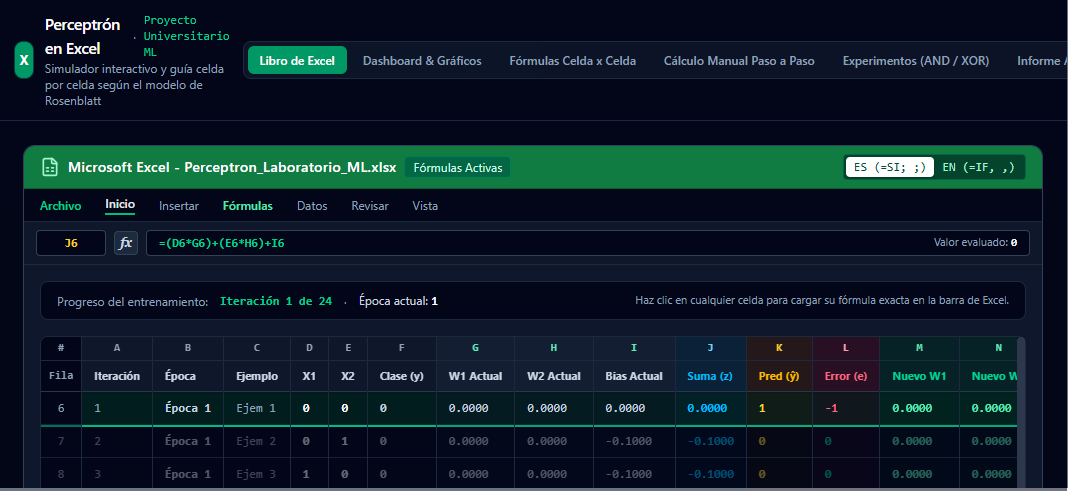

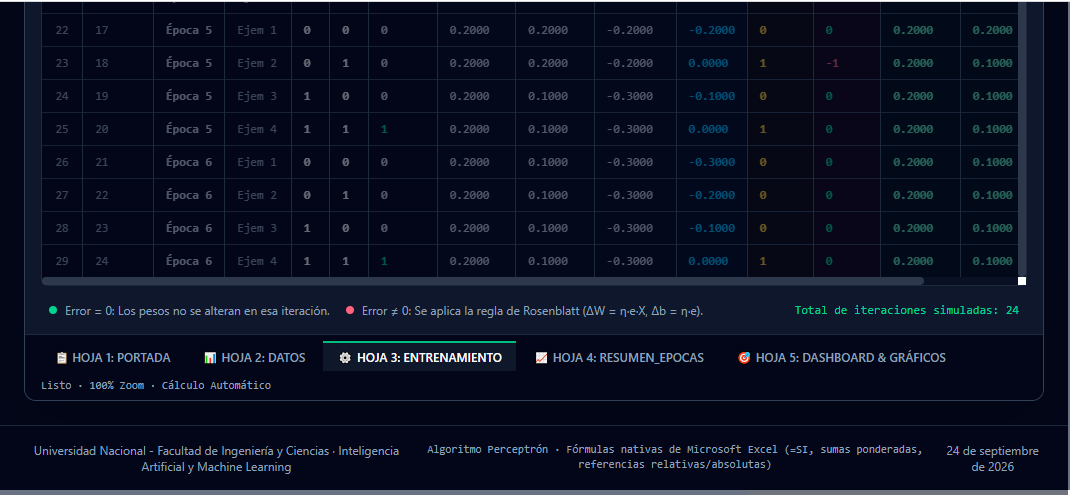

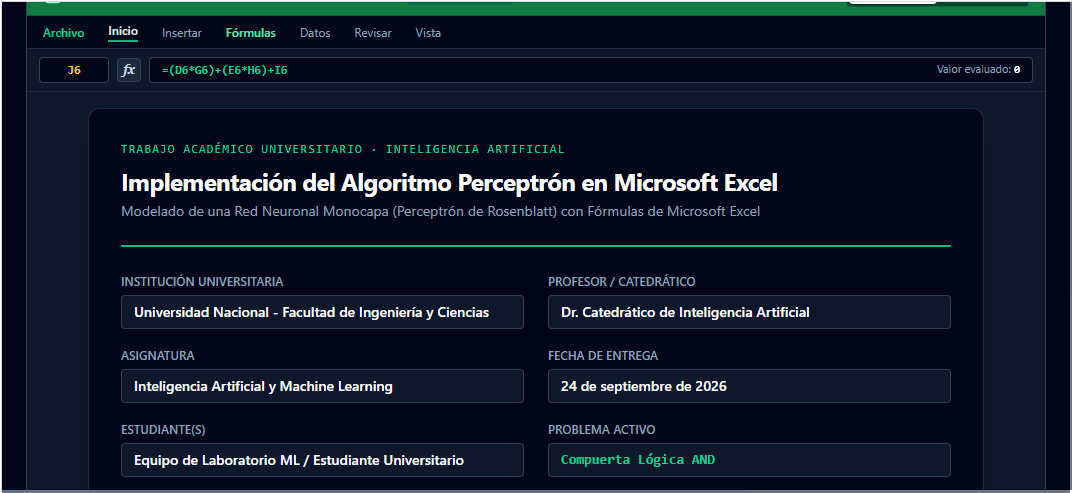

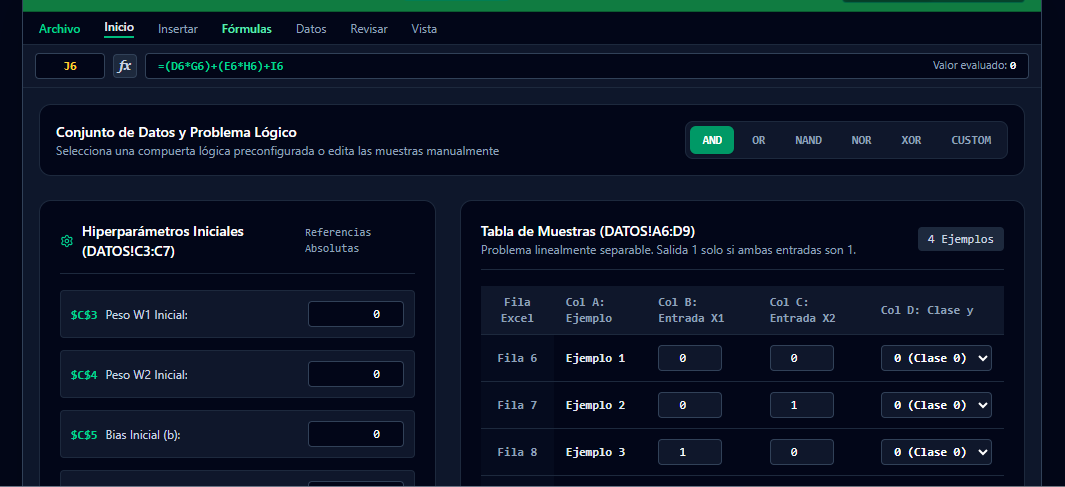

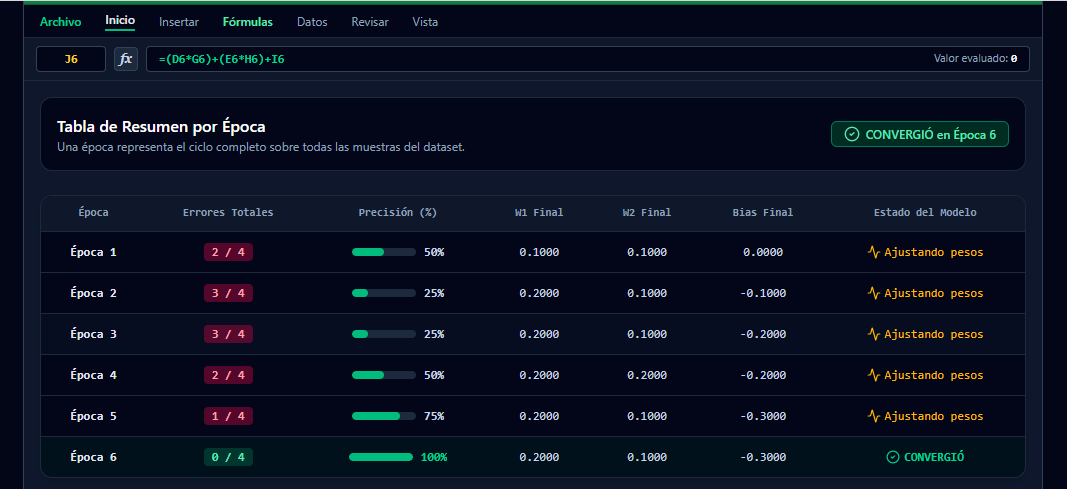

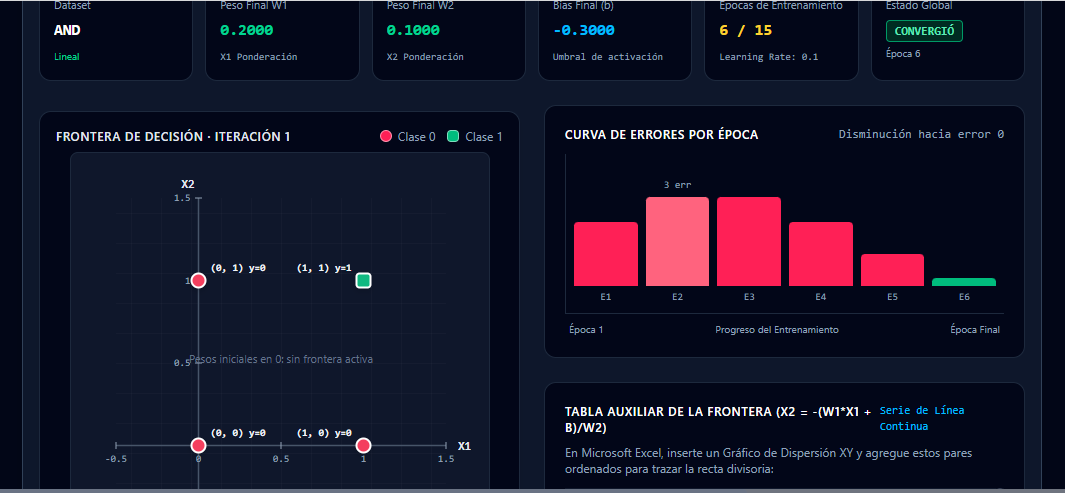